<a href="https://www.kaggle.com/code/nicapotato/ai-workforce-displacement-eda?scriptVersionId=319350266" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# AI workforce displacement and automation — global panel EDA

Dataset: [itszubi/ai-workforce-displacement-and-automation-trends](https://www.kaggle.com/datasets/itszubi/ai-workforce-displacement-and-automation-trends).

**Grain:** one row per **country × industry sector × calendar quarter** (balanced panel: 80 countries × 10 sectors × 26 quarters → 20,800 rows).

`data_source_notes` indicates **research-calibrated synthetic** indicators. Use this notebook for **patterns and associations**, not causal claims about real economies.

**Objective:** change over time, **quarter-over-quarter velocity** of key metrics (especially by sector), and cross-sectional patterns by **country**, **sector**, **region**, and **income group**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import kagglehub
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)

CSV_BASENAME = "ai_workforce_displacement_global_2020_2026.csv"
EXPECTED_COLS = [
    "record_id",
    "country",
    "iso3_code",
    "region",
    "income_group",
    "year",
    "quarter",
    "quarter_label",
    "industry_sector",
    "sector_automation_risk_score",
    "gdp_per_capita_usd",
    "ai_adoption_index",
    "pct_sector_workforce_displaced",
    "pct_sector_workforce_new_roles_created",
    "net_workforce_change_pct",
    "ai_cited_layoff_announcements",
    "ai_skill_wage_premium_pct",
    "pct_workforce_female",
    "pct_displaced_roles_female",
    "reskilling_programs_count",
    "govt_ai_policy_score_1_to_10",
    "ai_tool_adoption_pct",
    "data_source_notes",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            assert p.is_file()
            return p
        for p in kaggle_root.rglob("*.csv"):
            if "displacement" in p.name.lower():
                assert p.is_file()
                return p
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(
        kagglehub.dataset_download(
            "itszubi/ai-workforce-displacement-and-automation-trends"
        )
    )
    p = root / CSV_BASENAME
    assert p.exists(), f"expected {CSV_BASENAME} under {root}"
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert df.shape[0] > 0 and df.shape[1] == len(EXPECTED_COLS)

print(df.shape[0], "rows ×", df.shape[1], "cols")
display(df.sample(5, random_state=7))
display(df.dtypes)

CSV: /kaggle/input/datasets/itszubi/ai-workforce-displacement-and-automation-trends/ai_workforce_displacement_global_2020_2026.csv
20800 rows × 23 cols


,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,...,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct,data_source_notes
8602,8603,Kenya,KEN,Africa,Lower Middle Income,2020,3,2020-Q3,Healthcare & Life Sciences,0.211,...,0.0014,-0.0019,3,0.173,0.72,0.770,9,3.6,0.081,Research-calibrated synthetic data. Grounded i...
6334,6335,Austria,AUT,Europe,High Income,2022,2,2022-Q2,Retail & E-Commerce,0.712,...,0.1052,-0.0094,121,0.404,0.54,0.574,49,7.0,0.579,Research-calibrated synthetic data. Grounded i...
7974,7975,South Africa,ZAF,Africa,Upper Middle Income,2024,2,2024-Q2,Retail & E-Commerce,0.647,...,0.0272,-0.0217,98,0.367,0.54,0.537,26,5.7,0.424,Research-calibrated synthetic data. Grounded i...
8567,8568,Egypt,EGY,Middle East/Africa,Lower Middle Income,2026,1,2026-Q1,Media & Communications,0.559,...,0.0184,-0.0364,145,0.483,0.46,0.464,16,4.0,0.449,Research-calibrated synthetic data. Grounded i...
1814,1815,India,IND,South Asia,Lower Middle Income,2026,2,2026-Q2,Retail & E-Commerce,0.702,...,0.0345,-0.0500,137,0.556,0.54,0.533,15,4.2,0.590,Research-calibrated synthetic data. Grounded i...


record_id                                   int64
country                                    object
iso3_code                                  object
region                                     object
income_group                               object
year                                        int64
quarter                                     int64
quarter_label                              object
industry_sector                            object
sector_automation_risk_score              float64
gdp_per_capita_usd                          int64
ai_adoption_index                         float64
pct_sector_workforce_displaced            float64
pct_sector_workforce_new_roles_created    float64
net_workforce_change_pct                  float64
ai_cited_layoff_announcements               int64
ai_skill_wage_premium_pct                 float64
pct_workforce_female                      float64
pct_displaced_roles_female                float64
reskilling_programs_count                   int64


## 1 — Univariate: panel structure and marginals

In [2]:
cat_cols = ["country", "iso3_code", "region", "income_group", "industry_sector", "year", "quarter", "quarter_label"]
for c in cat_cols:
    vc = df[c].value_counts()
    print(f"\n=== {c} (n_unique={df[c].nunique()}) ===")
    print(vc.head(12).to_string())
    if df[c].nunique() > 12:
        print("...")

expected_groups = df["country"].nunique() * df["industry_sector"].nunique()
got = df.groupby(["country", "industry_sector"], observed=True).ngroups
assert got == expected_groups, f"country×sector groups {got} != {expected_groups}"
sizes = df.groupby(["country", "industry_sector"], observed=True).size()
assert sizes.min() == sizes.max(), "panel not balanced"
print("\nPanel: every country×sector has", int(sizes.iloc[0]), "quarters")


=== country (n_unique=80) ===
country
United States     260
China             260
Germany           260
United Kingdom    260
Japan             260
France            260
India             260
Canada            260
South Korea       260
Australia         260
Brazil            260
Italy             260
...

=== iso3_code (n_unique=80) ===
iso3_code
USA    260
CHN    260
DEU    260
GBR    260
JPN    260
FRA    260
IND    260
CAN    260
KOR    260
AUS    260
BRA    260
ITA    260
...

=== region (n_unique=12) ===
region
Europe                5200
Latin America         3380
Africa                3380
Southeast Asia        2080
Middle East           1820
East Asia             1300
South Asia            1300
North America          520
Oceania                520
Europe/Asia            520
Central Asia           520
Middle East/Africa     260

=== income_group (n_unique=4) ===
income_group
High Income            8060
Lower Middle Income    6240
Upper Middle Income    5720
Low Income           

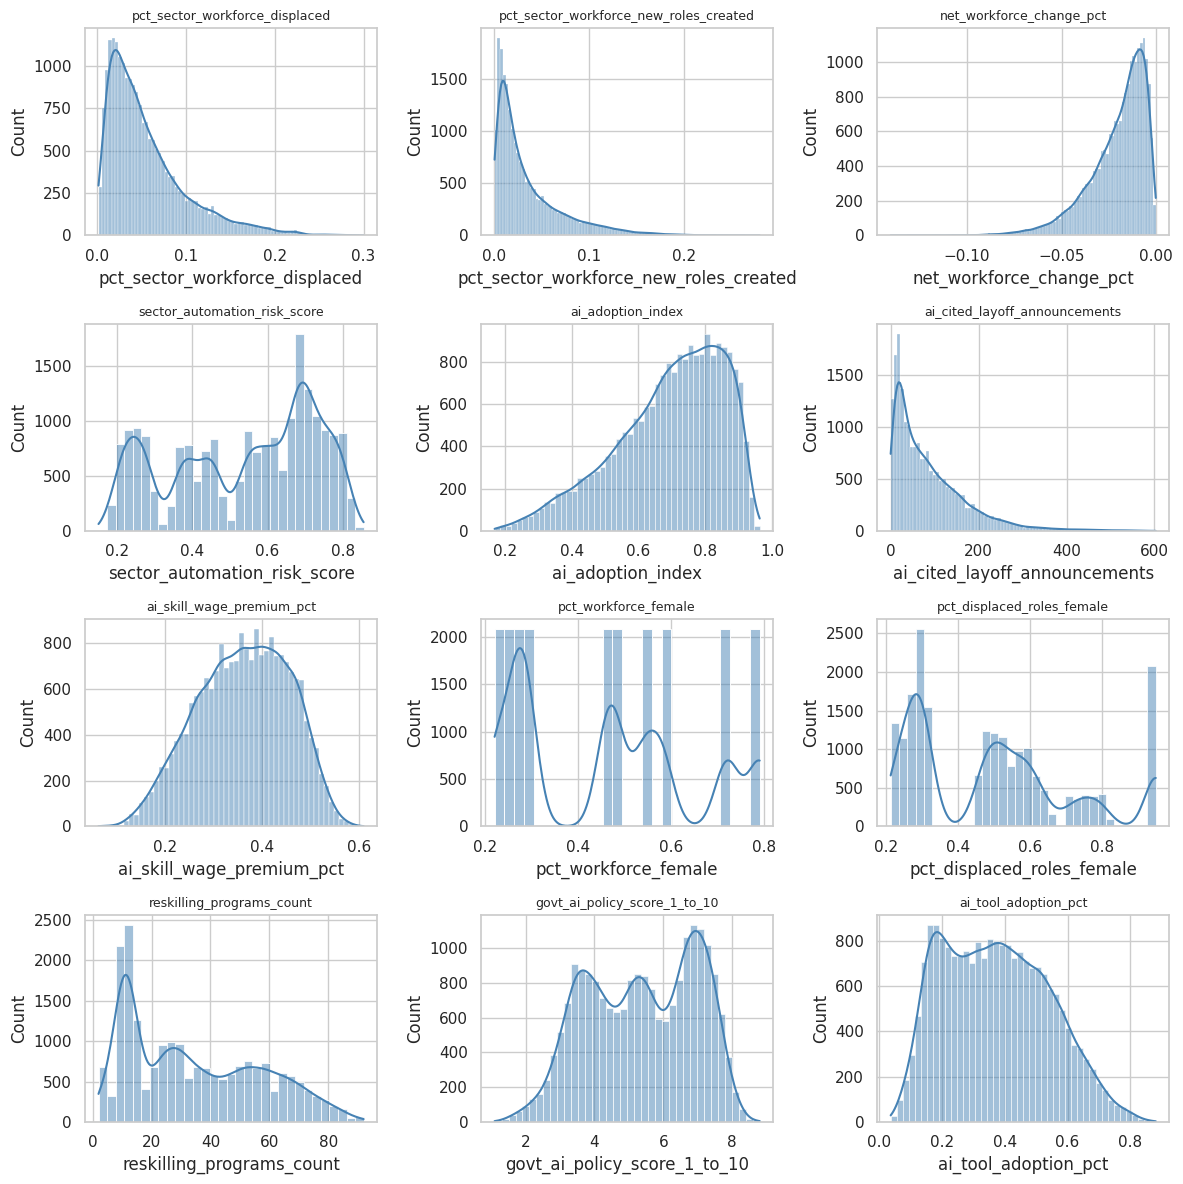

In [3]:
cont = [
    "pct_sector_workforce_displaced",
    "pct_sector_workforce_new_roles_created",
    "net_workforce_change_pct",
    "sector_automation_risk_score",
    "ai_adoption_index",
    "ai_cited_layoff_announcements",
    "ai_skill_wage_premium_pct",
    "pct_workforce_female",
    "pct_displaced_roles_female",
    "reskilling_programs_count",
    "govt_ai_policy_score_1_to_10",
    "ai_tool_adoption_pct",
]
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
axes = axes.ravel()
for ax, col in zip(axes, cont):
    s = df[col].dropna()
    sns.histplot(s, kde=True, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation (univariate):** Counts confirm a **balanced quarterly panel** (fixed country × sector coverage). Distributions are synthetic-smooth: use them to compare **relative** spread and tails across metrics, not to infer real-world frequency of extreme events.

## 2 — Time ordering and quarter-over-quarter velocity

In [4]:
key_numeric = [
    "pct_sector_workforce_displaced",
    "net_workforce_change_pct",
    "sector_automation_risk_score",
    "ai_adoption_index",
    "ai_cited_layoff_announcements",
]

df = df.sort_values(
    ["country", "iso3_code", "industry_sector", "year", "quarter"]
).reset_index(drop=True)

df["period"] = pd.PeriodIndex.from_fields(
    year=df["year"].astype(int),
    quarter=df["quarter"].astype(int),
    freq="Q-DEC",
)
df["period_ordinal"] = df["period"].apply(lambda p: p.ordinal)

group_keys = ["country", "industry_sector"]
for col in key_numeric:
    dcol = f"dQ_{col}"
    df[dcol] = df.groupby(group_keys, observed=True)[col].diff()

velocity = df.loc[
    df[[f"dQ_{c}" for c in key_numeric]].notna().all(axis=1)
].copy()
print("rows with full QoQ deltas:", len(velocity))
display(velocity[key_numeric + [f"dQ_{c}" for c in key_numeric]].describe().T)

rows with full QoQ deltas: 20000


,count,mean,std,min,25%,50%,75%,max
pct_sector_workforce_displaced,20000.0,0.057438,0.045038,0.0020,0.0244,0.0445,0.0765,0.3000
net_workforce_change_pct,20000.0,-0.021022,0.015374,-0.1403,-0.0288,-0.0170,-0.0095,-0.0003
sector_automation_risk_score,20000.0,0.537852,0.190358,0.1510,0.3790,0.5800,0.6980,0.8550
ai_adoption_index,20000.0,0.699267,0.155271,0.1910,0.6000,0.7240,0.8240,0.9630
ai_cited_layoff_announcements,20000.0,91.057250,85.705385,1.0000,26.0000,67.0000,130.0000,603.0000
dQ_pct_sector_workforce_displaced,20000.0,0.002690,0.011824,-0.0677,-0.0022,0.0018,0.0070,0.0952
dQ_net_workforce_change_pct,20000.0,-0.001058,0.012879,-0.1063,-0.0053,-0.0008,0.0032,0.1093
dQ_sector_automation_risk_score,20000.0,-0.000035,0.028056,-0.1220,-0.0190,0.0000,0.0190,0.1230
dQ_ai_adoption_index,20000.0,0.012264,0.018114,-0.0630,0.0000,0.0120,0.0250,0.0870
dQ_ai_cited_layoff_announcements,20000.0,5.765500,38.865932,-257.0000,-7.0000,3.0000,18.0000,309.0000


**QoQ deltas:** For `ai_cited_layoff_announcements` we use **simple differences** (not percent change). Other fields use point changes in their native units (percent metrics as percentage points; `ai_adoption_index` as index points).

Median |QoQ Δ displacement| by sector (across all country-sector quarters):
industry_sector
Administrative & Clerical     0.00855
Manufacturing & Industry      0.00715
Retail & E-Commerce           0.00695
Transportation & Logistics    0.00650
Finance & Banking             0.00580
Media & Communications        0.00520
Technology & Software         0.00430
Energy & Utilities            0.00410
Education & Research          0.00240
Healthcare & Life Sciences    0.00200


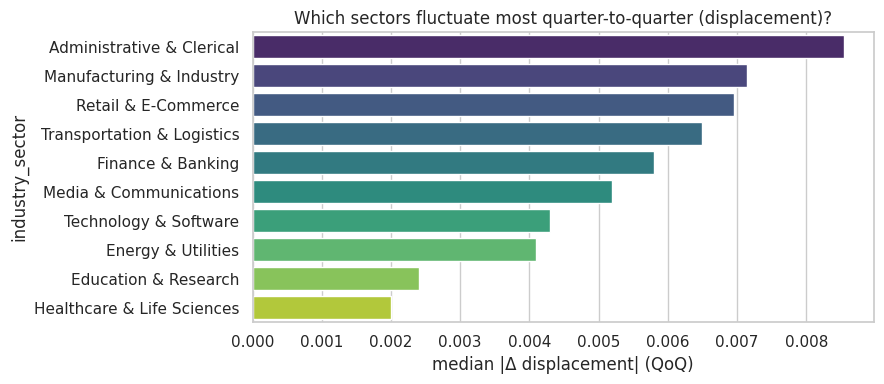

In [5]:
abs_d = velocity.groupby("industry_sector", observed=True)[
    "dQ_pct_sector_workforce_displaced"
].apply(lambda s: s.abs().median()).sort_values(ascending=False)
print("Median |QoQ Δ displacement| by sector (across all country-sector quarters):")
print(abs_d.to_string())

plt.figure(figsize=(9, 4))
sns.barplot(x=abs_d.values, y=abs_d.index, hue=abs_d.index, palette="viridis", legend=False)
plt.xlabel("median |Δ displacement| (QoQ)")
plt.title("Which sectors fluctuate most quarter-to-quarter (displacement)?")
plt.tight_layout()
plt.show()

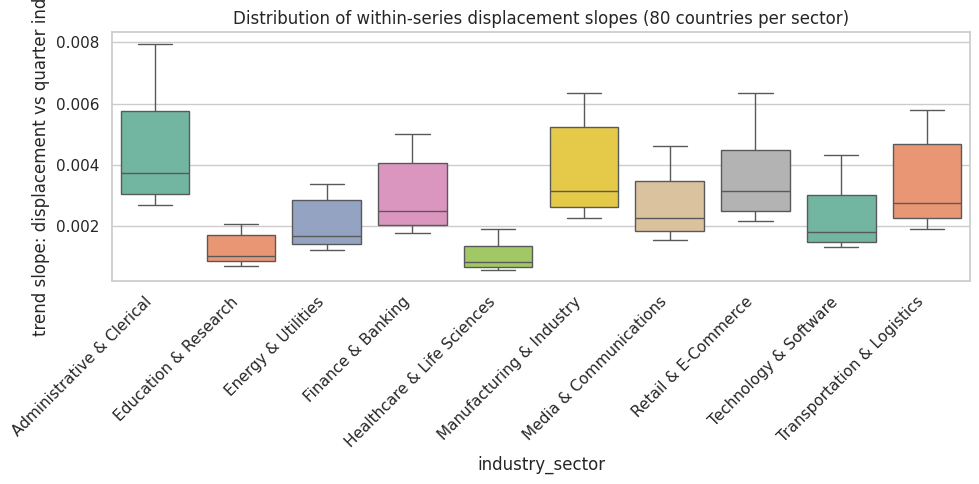

In [6]:
records = []
for (ctry, sec), g in df.groupby(["country", "industry_sector"], observed=True):
    g = g.sort_values("period_ordinal")
    t = g["period_ordinal"].to_numpy(dtype=float)
    y = g["pct_sector_workforce_displaced"].to_numpy(dtype=float)
    if len(t) >= 3:
        slope, intercept, r, p, se = stats.linregress(t, y)
        records.append(
            {
                "country": ctry,
                "industry_sector": sec,
                "slope_disp_per_quarter": slope,
                "r2_disp": r**2,
            }
        )

slopes_df = pd.DataFrame.from_records(records)
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=slopes_df,
    x="industry_sector",
    y="slope_disp_per_quarter",
    hue="industry_sector",
    palette="Set2",
    legend=False,
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("trend slope: displacement vs quarter index")
plt.title("Distribution of within-series displacement slopes (80 countries per sector)")
plt.tight_layout()
plt.show()

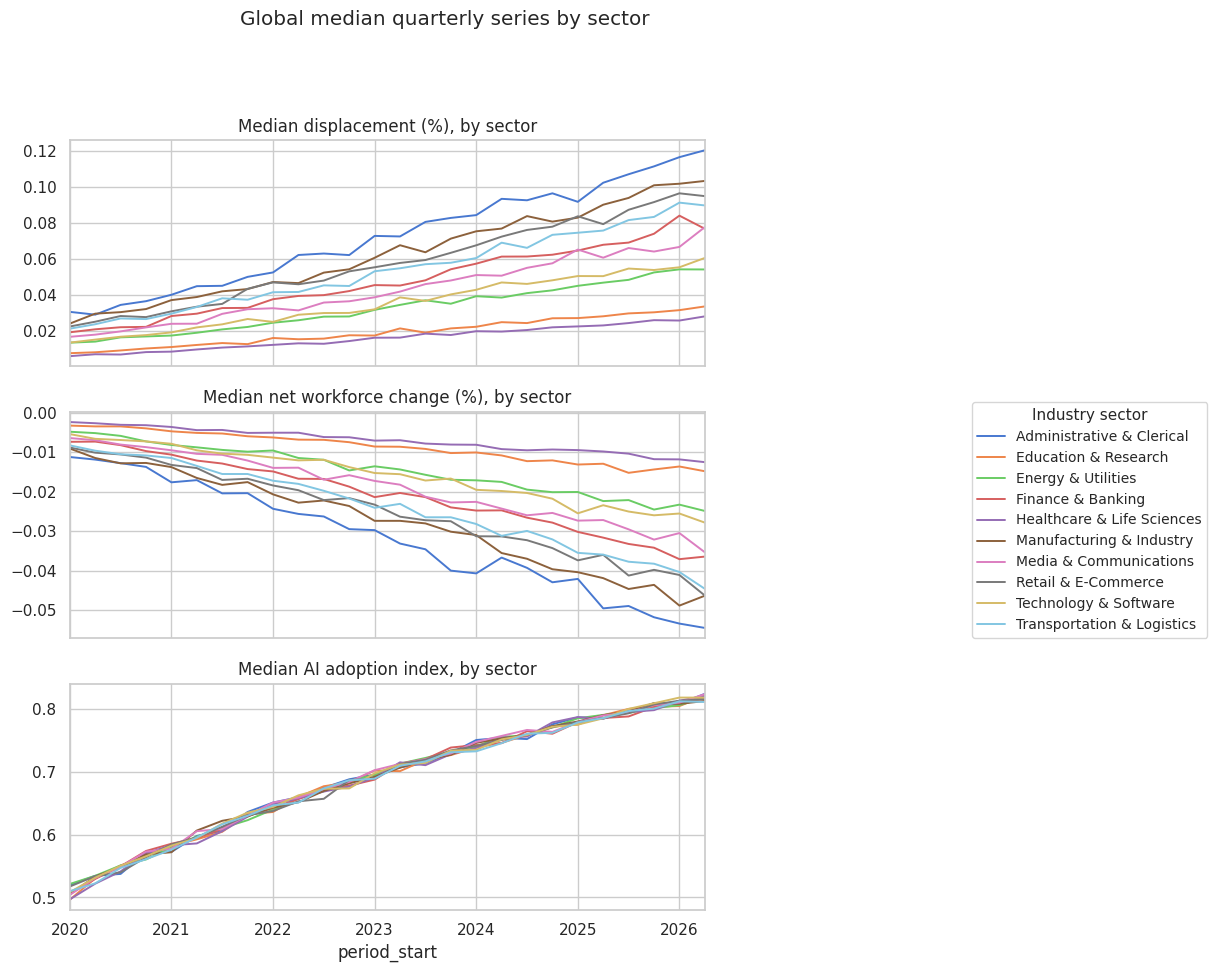

In [7]:
qg = (
    df.groupby(["period", "industry_sector"], observed=True)[
        ["pct_sector_workforce_displaced", "net_workforce_change_pct", "ai_adoption_index"]
    ]
    .median()
    .reset_index()
)
qg["period_start"] = qg["period"].dt.start_time

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
line_handles, line_labels = None, None
for ax, col, title in zip(
    axes,
    [
        "pct_sector_workforce_displaced",
        "net_workforce_change_pct",
        "ai_adoption_index",
    ],
    [
        "Median displacement (%), by sector",
        "Median net workforce change (%), by sector",
        "Median AI adoption index, by sector",
    ],
):
    wide = qg.pivot(index="period_start", columns="industry_sector", values=col)
    wide.plot(ax=ax, legend=False, title=title, lw=1.4)
    if line_handles is None:
        line_handles, line_labels = ax.get_legend_handles_labels()

fig.legend(
    line_handles,
    line_labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=10,
    title="Industry sector",
    title_fontsize=11,
    frameon=True,
    markerscale=2.0,
)
fig.subplots_adjust(right=0.76)
fig.suptitle("Global median quarterly series by sector", y=1.01)
plt.show()


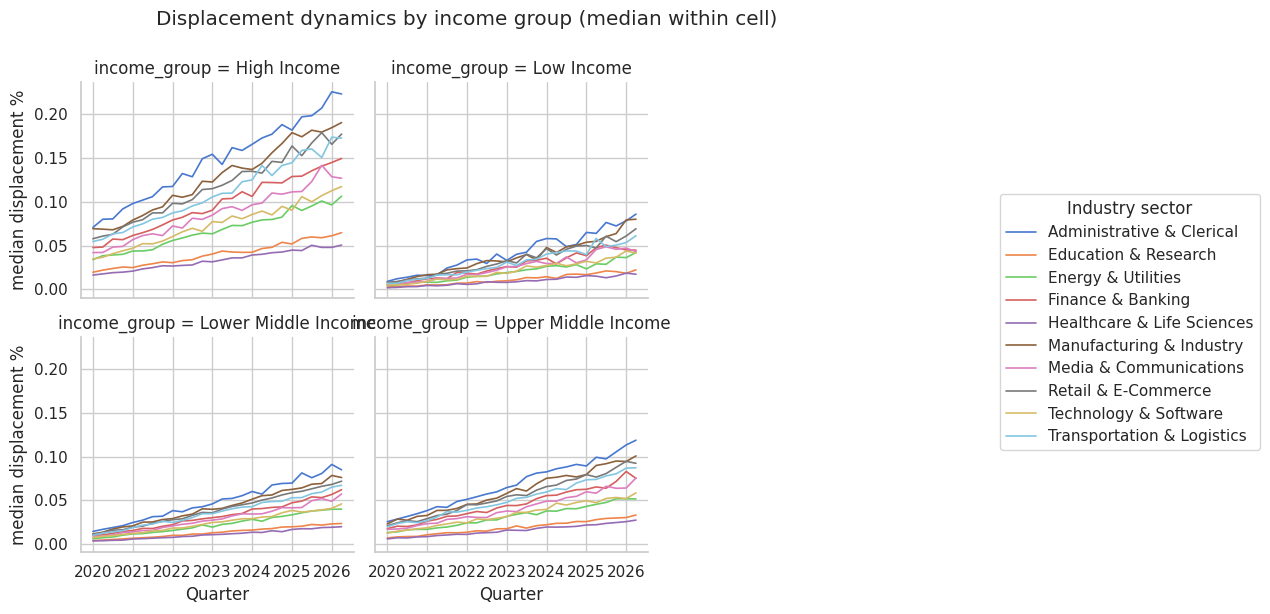

In [8]:
ig = (
    df.groupby(["period", "income_group", "industry_sector"], observed=True)[
        "pct_sector_workforce_displaced"
    ]
    .median()
    .reset_index()
)
ig["period_start"] = ig["period"].dt.start_time

g = sns.relplot(
    data=ig,
    x="period_start",
    y="pct_sector_workforce_displaced",
    hue="industry_sector",
    col="income_group",
    col_wrap=2,
    kind="line",
    facet_kws={"sharey": True},
    height=3,
    aspect=1.25,
    linewidth=1.2,
)
g.set_axis_labels("Quarter", "median displacement %")
g.fig.suptitle("Displacement dynamics by income group (median within cell)", y=1.02)
if g._legend is not None:
    sns.move_legend(
        g,
        "center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        fontsize=11,
        title="Industry sector",
        title_fontsize=12,
        markerscale=2.5,
    )
g.fig.subplots_adjust(right=0.68, top=0.90)
plt.show()


## 3 — Country × sector structure

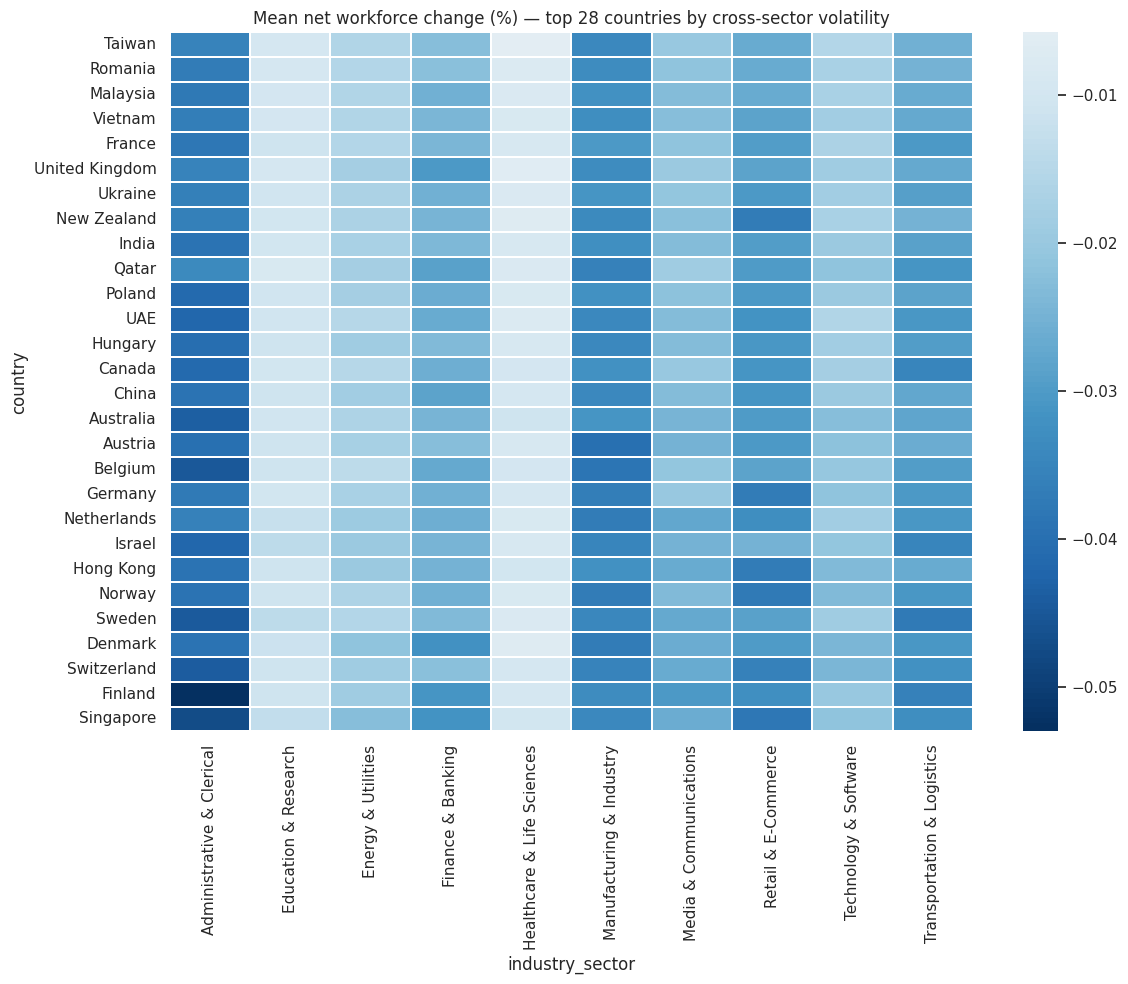

In [9]:
country_metric = (
    df.groupby(["country", "industry_sector"], observed=True)["net_workforce_change_pct"]
    .mean()
    .reset_index()
)
country_spread = (
    country_metric.groupby("country")["net_workforce_change_pct"].std().sort_values(ascending=False)
)
top_n = 28
use_countries = country_spread.index[:top_n]
hm_df = country_metric[country_metric["country"].isin(use_countries)]
pivot = hm_df.pivot(index="country", columns="industry_sector", values="net_workforce_change_pct")
pivot = pivot.reindex(pivot.mean(axis=1).sort_values(ascending=False).index)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot, cmap="RdBu_r", center=0, linewidths=0.01)
plt.title(
    f"Mean net workforce change (%) — top {top_n} countries by cross-sector volatility"
)
plt.tight_layout()
plt.show()

### Heatmaps across continuous outcomes

Row-normalized cells: **region × sector** and **income group × sector** for several mean outcomes (panel collapsed to two-way tables). Diverging colors use **0 as center** only when the table spans both signs.


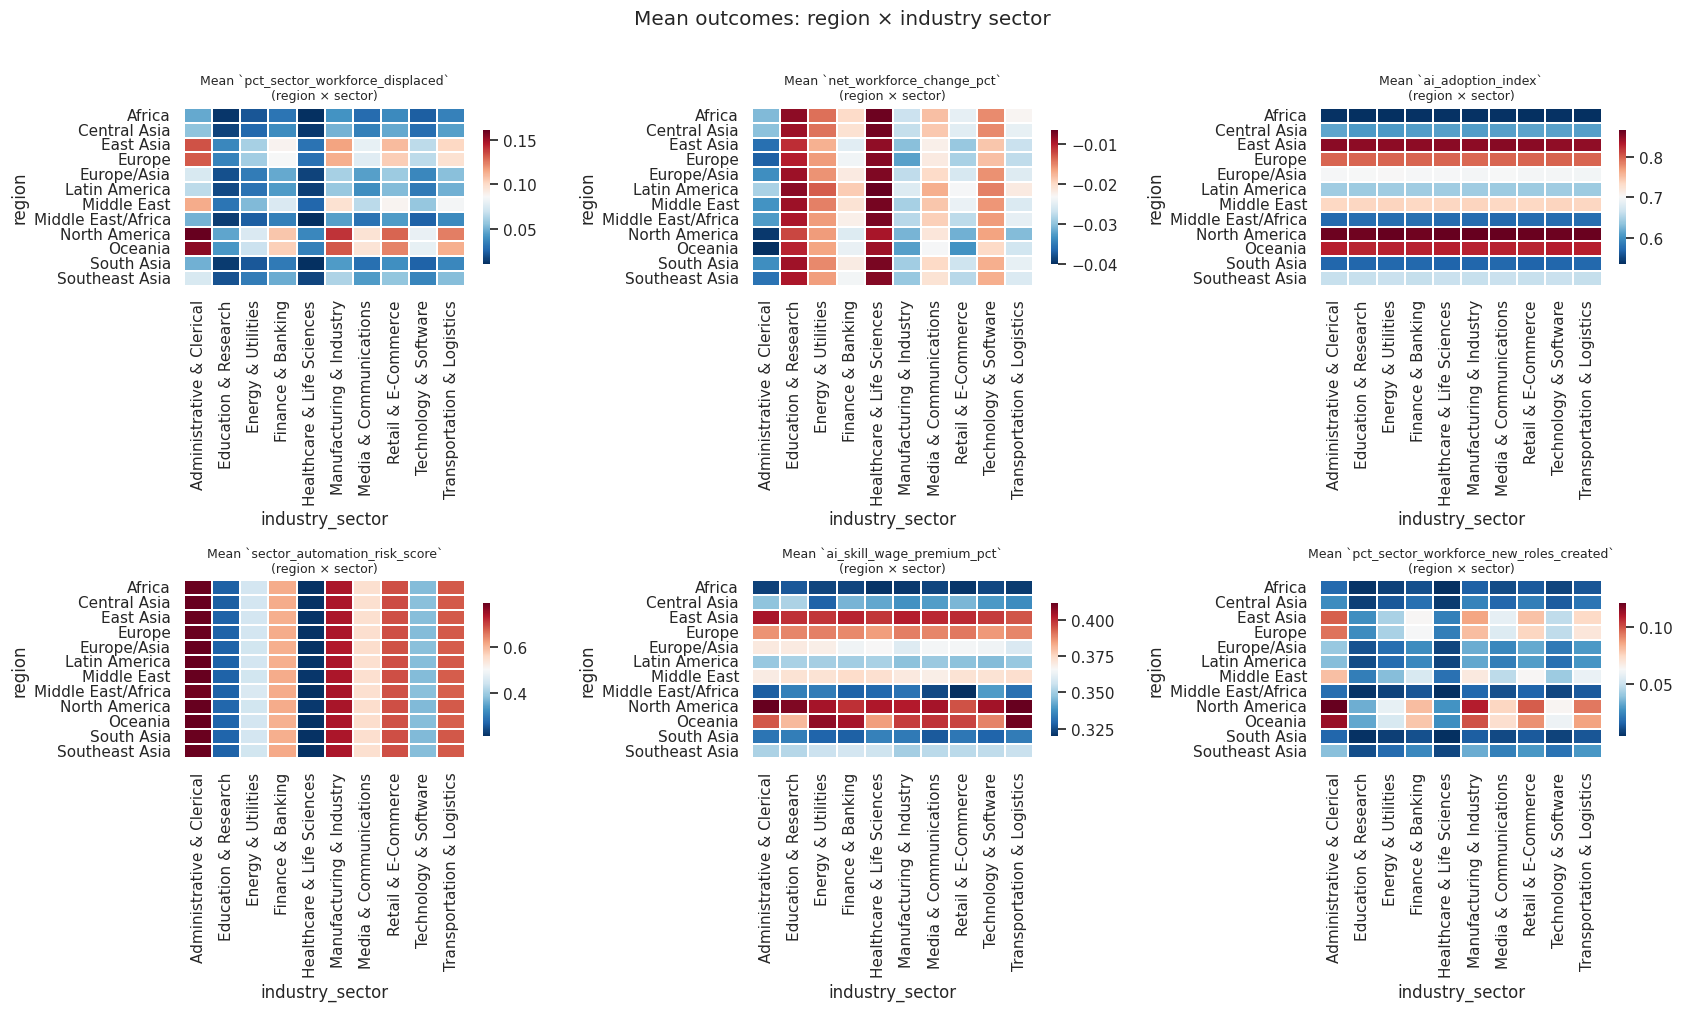

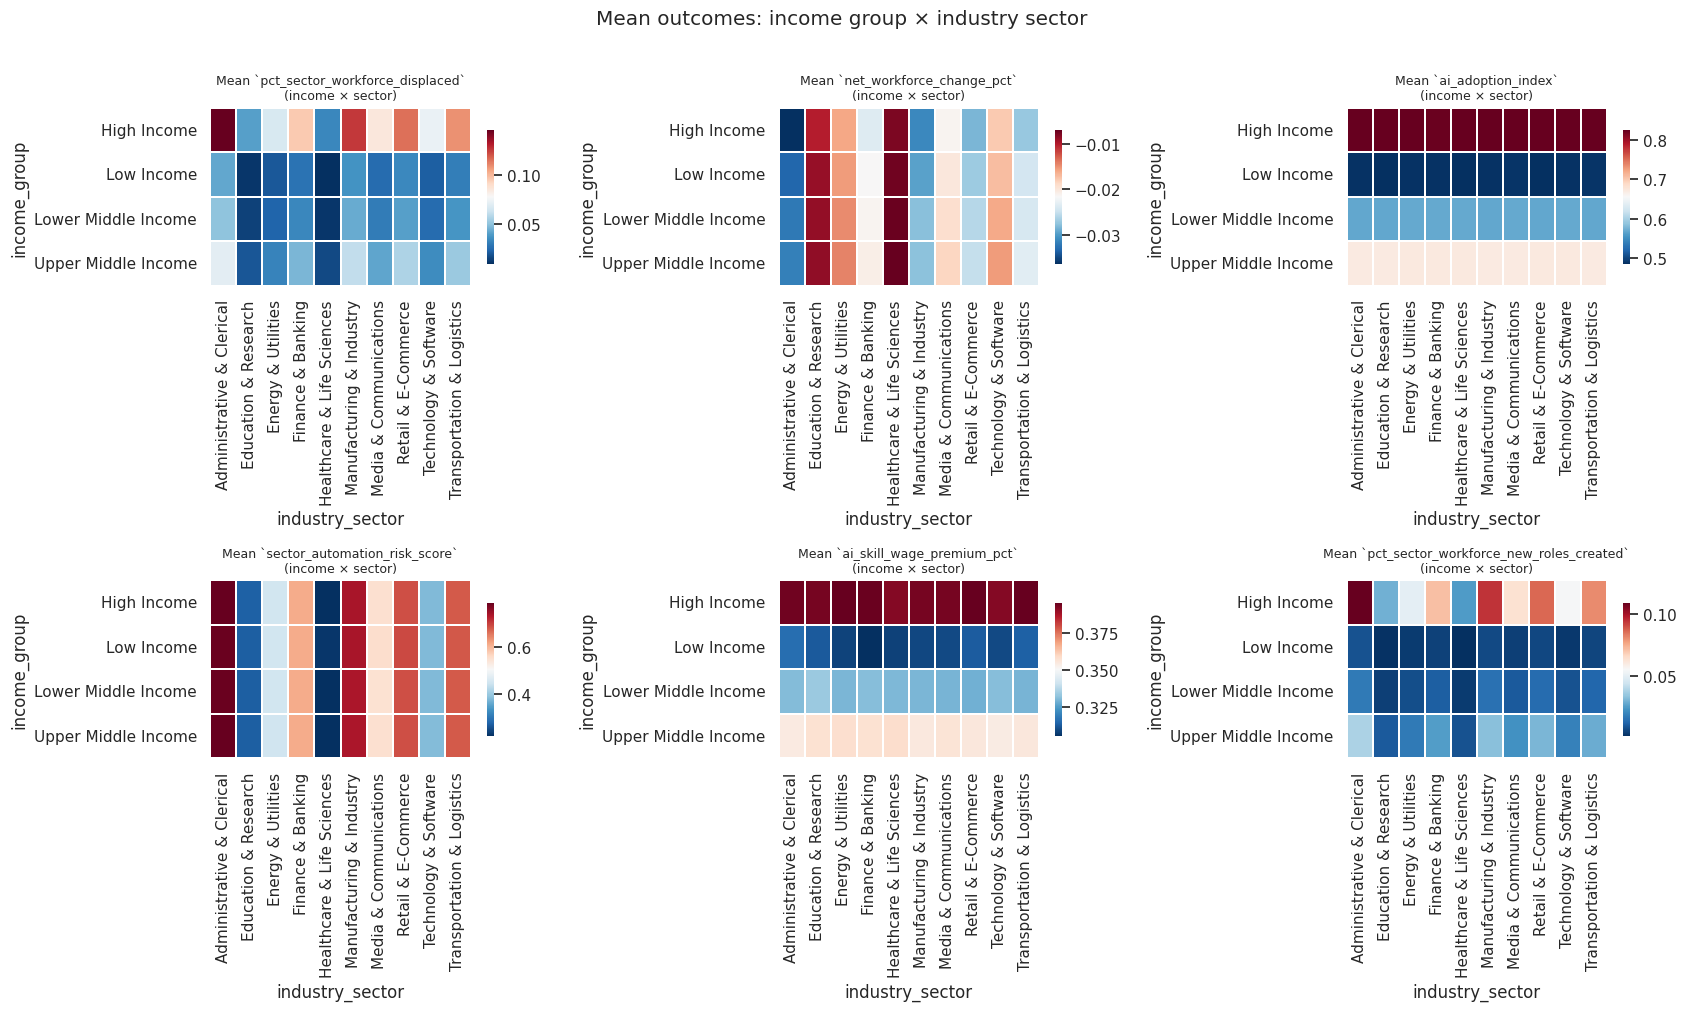

In [10]:
heatmap_metrics = [
    "pct_sector_workforce_displaced",
    "net_workforce_change_pct",
    "ai_adoption_index",
    "sector_automation_risk_score",
    "ai_skill_wage_premium_pct",
    "pct_sector_workforce_new_roles_created",
]

region_sector = df.groupby(["region", "industry_sector"], observed=True)[
    heatmap_metrics
].mean()
income_sector = df.groupby(["income_group", "industry_sector"], observed=True)[
    heatmap_metrics
].mean()


def heat_center(mat: pd.DataFrame):
    v = mat.to_numpy(dtype=float).ravel()
    v = v[np.isfinite(v)]
    if v.size == 0:
        return None
    return 0.0 if (v.min() < 0 < v.max()) else None


fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.ravel()
for ax, m in zip(axes, heatmap_metrics):
    mat = region_sector[m].unstack("industry_sector")
    sns.heatmap(
        mat,
        ax=ax,
        cmap="RdBu_r",
        center=heat_center(mat),
        linewidths=0.2,
        cbar_kws={"shrink": 0.75},
    )
    ax.set_title(f"Mean `{m}`\n(region × sector)", fontsize=9)
plt.suptitle("Mean outcomes: region × industry sector", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.ravel()
for ax, m in zip(axes, heatmap_metrics):
    mat = income_sector[m].unstack("industry_sector")
    sns.heatmap(
        mat,
        ax=ax,
        cmap="RdBu_r",
        center=heat_center(mat),
        linewidths=0.2,
        cbar_kws={"shrink": 0.75},
    )
    ax.set_title(f"Mean `{m}`\n(income × sector)", fontsize=9)
plt.suptitle("Mean outcomes: income group × industry sector", y=1.01)
plt.tight_layout()
plt.show()


In [11]:
# Country rankings: average QoQ displacement velocity (mean of dQ)
cvel = (
    velocity.groupby("country", observed=True)["dQ_pct_sector_workforce_displaced"]
    .mean()
    .sort_values()
)
print("Countries with lowest mean QoQ Δ displacement (most negative average):")
print(cvel.head(8).to_string())
print("\nCountries with highest mean QoQ Δ displacement:")
print(cvel.tail(8).to_string())

Countries with lowest mean QoQ Δ displacement (most negative average):
country
Cambodia       0.001622
Cameroon       0.001726
Tanzania       0.001733
Bolivia        0.001734
Ivory Coast    0.001736
Paraguay       0.001741
Ghana          0.001761
Vietnam        0.001782

Countries with highest mean QoQ Δ displacement:
country
Belgium      0.004142
Sweden       0.004146
Denmark      0.004151
Germany      0.004258
Canada       0.004363
Hong Kong    0.004388
Qatar        0.004424
Finland      0.004623


## 4 — Categorical × numeric (region, income, sector)

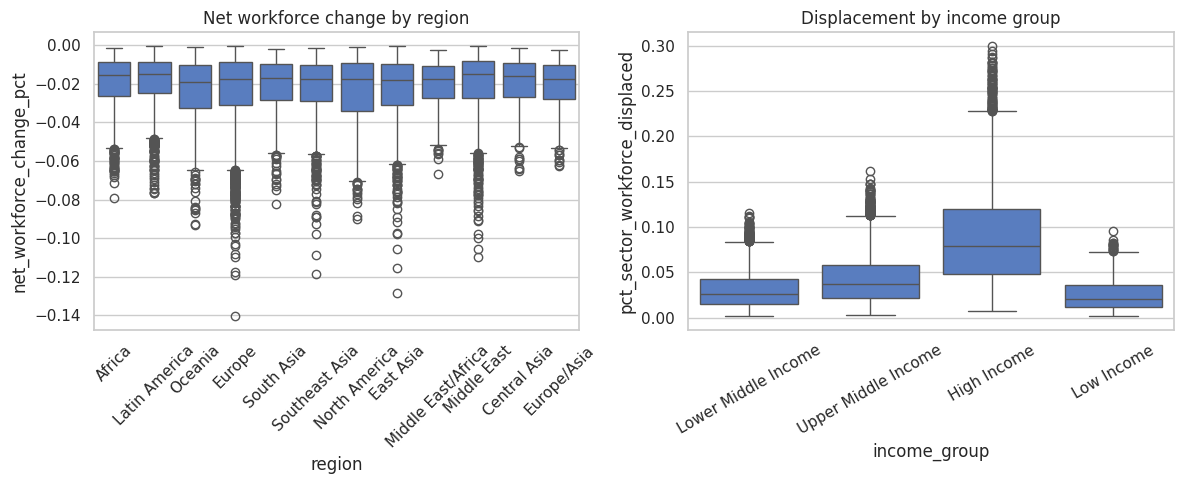

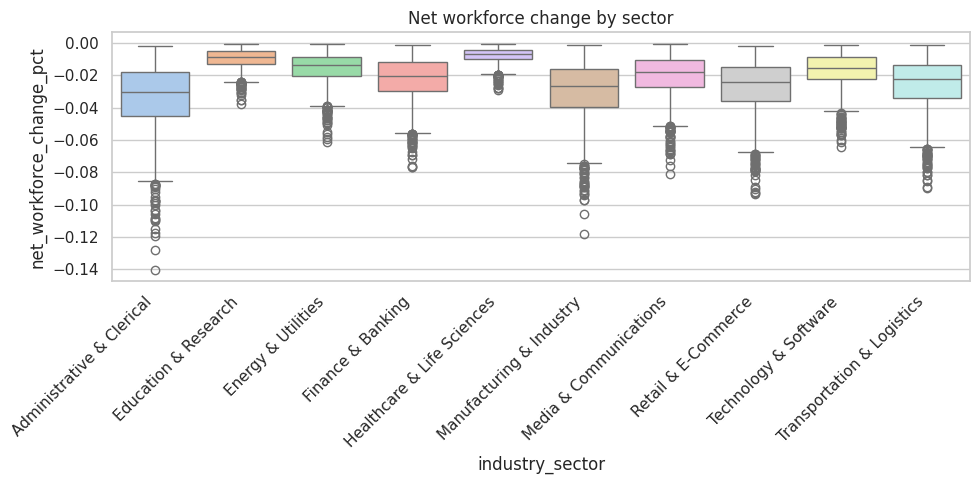

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="region", y="net_workforce_change_pct", ax=axes[0])
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Net workforce change by region")
sns.boxplot(data=df, x="income_group", y="pct_sector_workforce_displaced", ax=axes[1])
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_title("Displacement by income group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="industry_sector",
    y="net_workforce_change_pct",
    hue="industry_sector",
    palette="pastel",
    legend=False,
)
plt.xticks(rotation=45, ha="right")
plt.title("Net workforce change by sector")
plt.tight_layout()
plt.show()

## 5 — Multivariate: correlation, scatter, feature importances

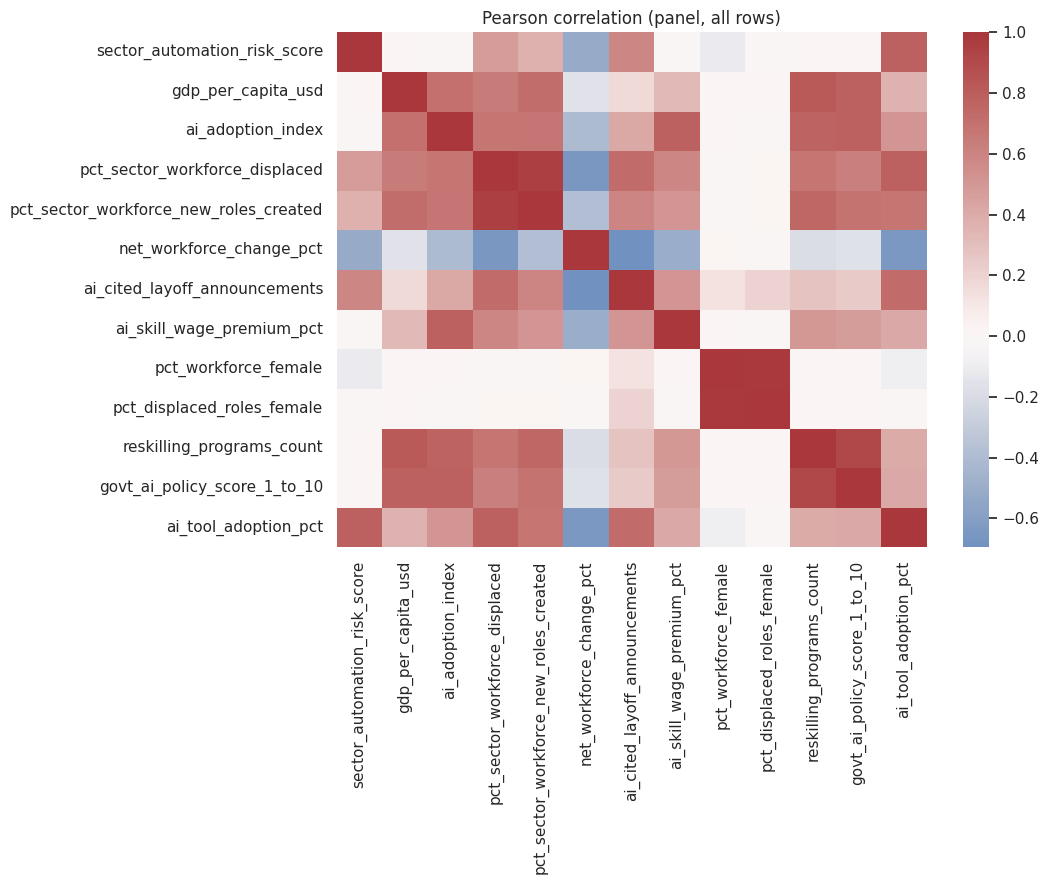

Largest |Pearson − Spearman| (robustness check, top 10):
                                                                                pearson  spearman      diff
ai_cited_layoff_announcements          pct_displaced_roles_female              0.199669 -0.078695  0.278364
pct_displaced_roles_female             ai_cited_layoff_announcements           0.199669 -0.078695  0.278364
ai_cited_layoff_announcements          pct_workforce_female                    0.131876 -0.072286  0.204162
pct_workforce_female                   ai_cited_layoff_announcements           0.131876 -0.072286  0.204162
ai_adoption_index                      pct_sector_workforce_new_roles_created  0.672701  0.843566  0.170864
pct_sector_workforce_new_roles_created ai_adoption_index                       0.672701  0.843566  0.170864
net_workforce_change_pct               pct_displaced_roles_female             -0.025538  0.102671  0.128209
pct_displaced_roles_female             net_workforce_change_pct               -

In [13]:
num_for_corr = [
    "sector_automation_risk_score",
    "gdp_per_capita_usd",
    "ai_adoption_index",
    "pct_sector_workforce_displaced",
    "pct_sector_workforce_new_roles_created",
    "net_workforce_change_pct",
    "ai_cited_layoff_announcements",
    "ai_skill_wage_premium_pct",
    "pct_workforce_female",
    "pct_displaced_roles_female",
    "reskilling_programs_count",
    "govt_ai_policy_score_1_to_10",
    "ai_tool_adoption_pct",
]
cm = df[num_for_corr].corr(method="pearson")
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=False, cmap="vlag", center=0)
plt.title("Pearson correlation (panel, all rows)")
plt.tight_layout()
plt.show()

# Spearman footnote pairs: show top by abs diff from Pearson for a few key targets
spe = df[num_for_corr].corr(method="spearman")
sub = pd.DataFrame({"pearson": cm.stack(), "spearman": spe.stack()}).join(
    pd.DataFrame({"diff": (cm - spe).abs().stack()}), how="left"
)
sub = sub[sub.index.get_level_values(0) != sub.index.get_level_values(1)]
print("Largest |Pearson − Spearman| (robustness check, top 10):")
print(sub.nlargest(10, "diff")[["pearson", "spearman", "diff"]].to_string())

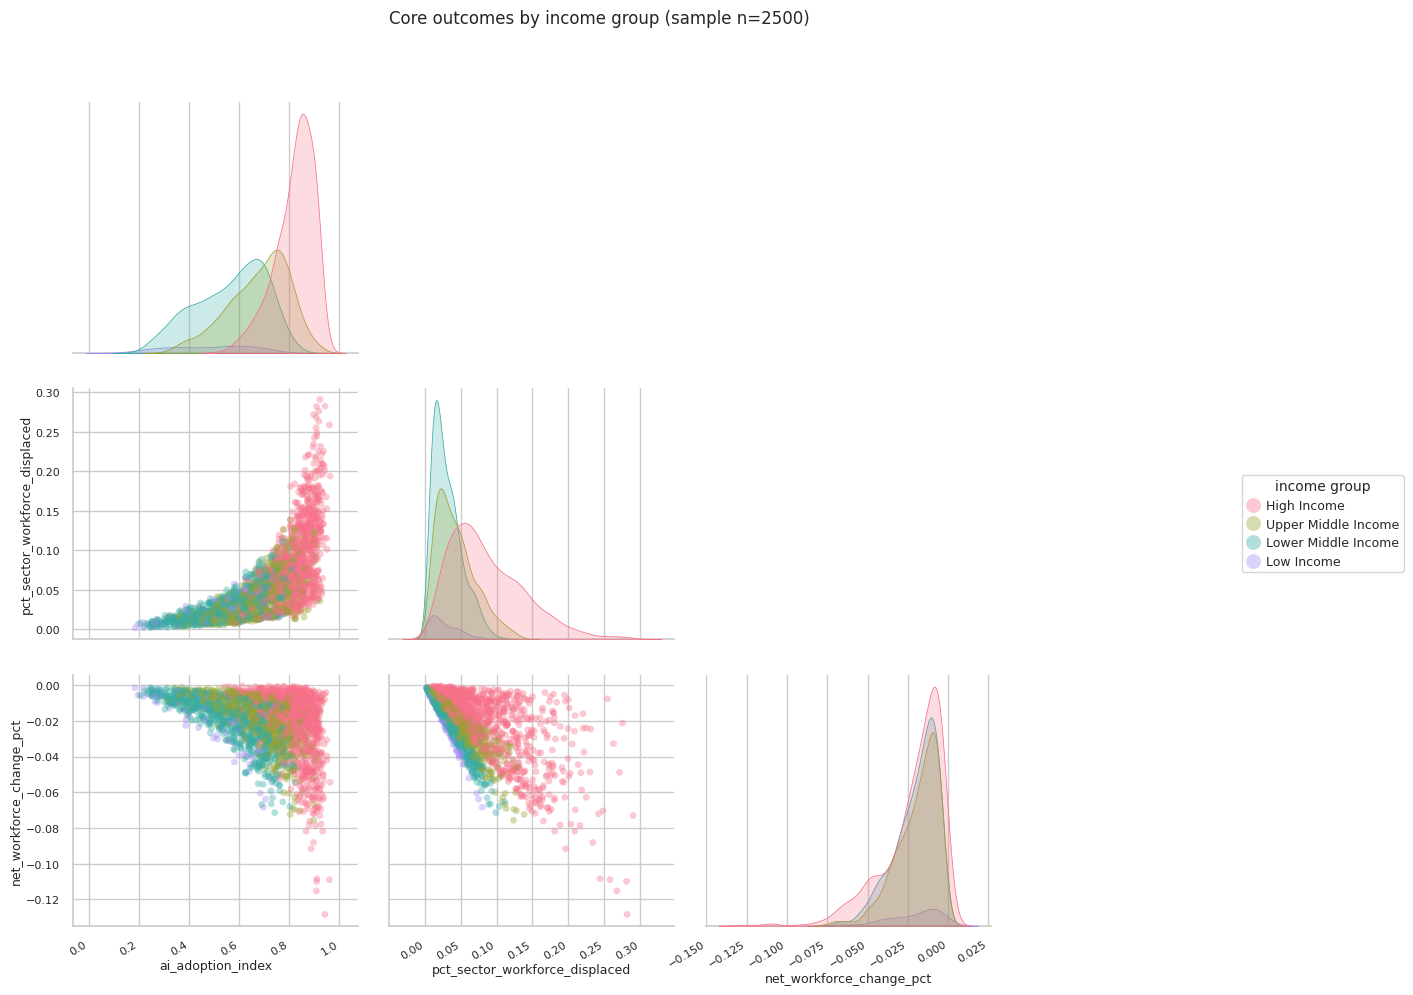

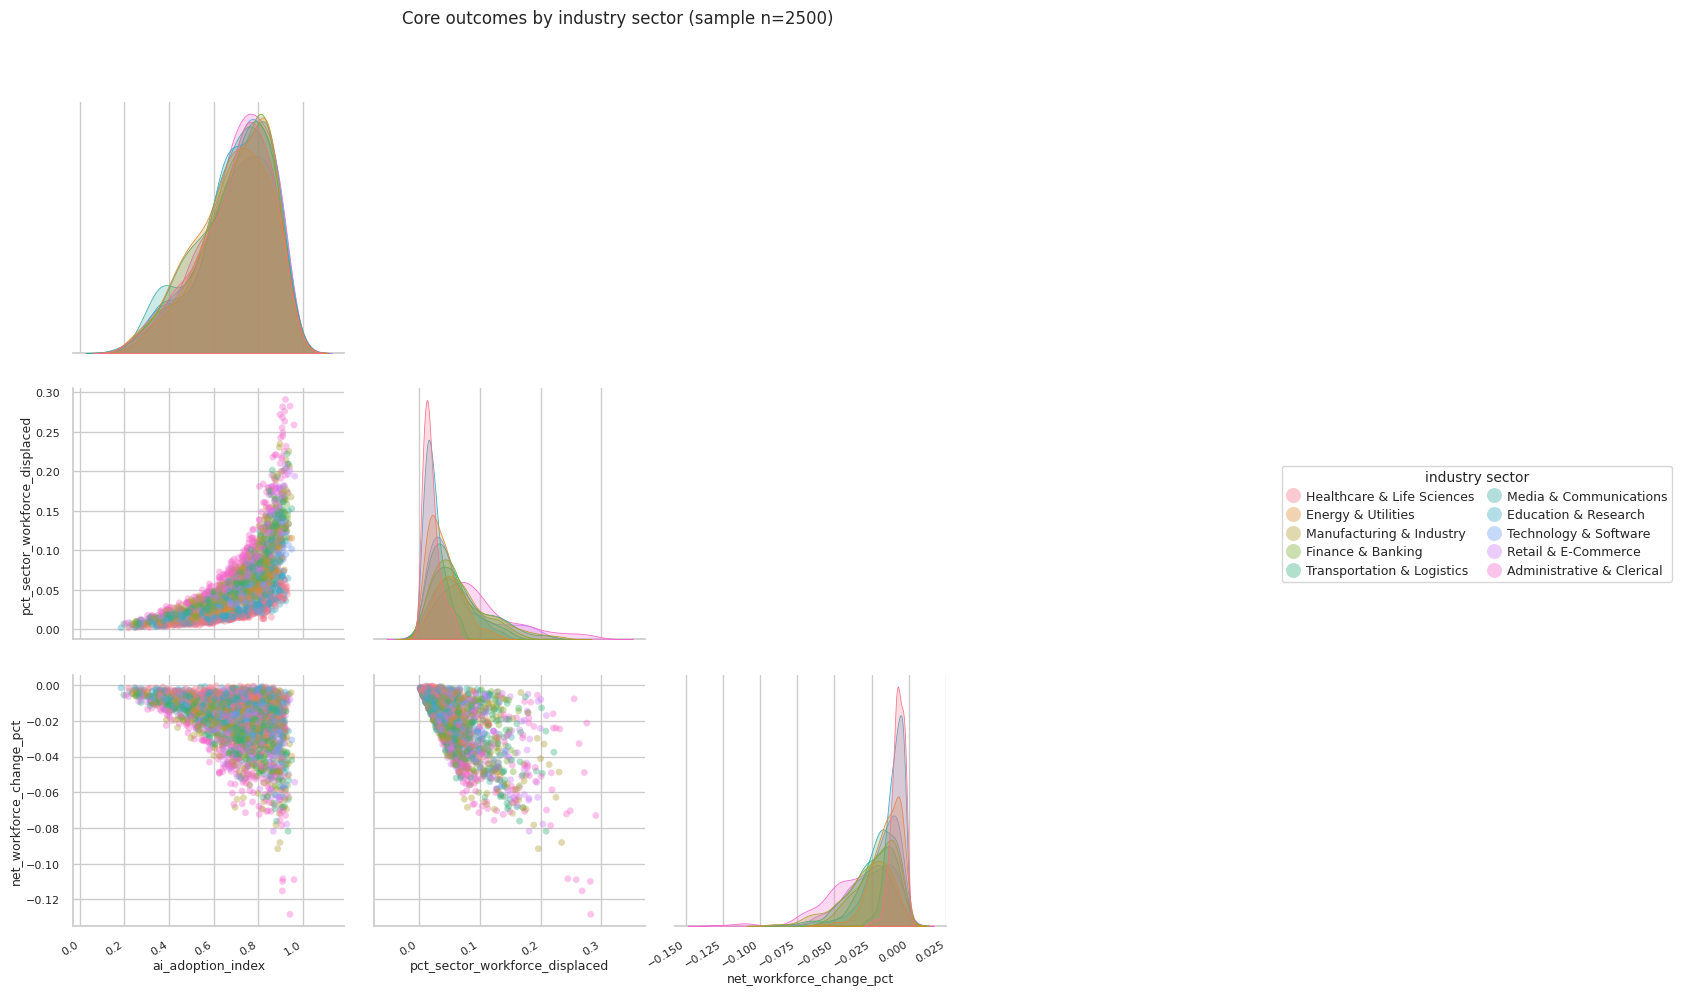

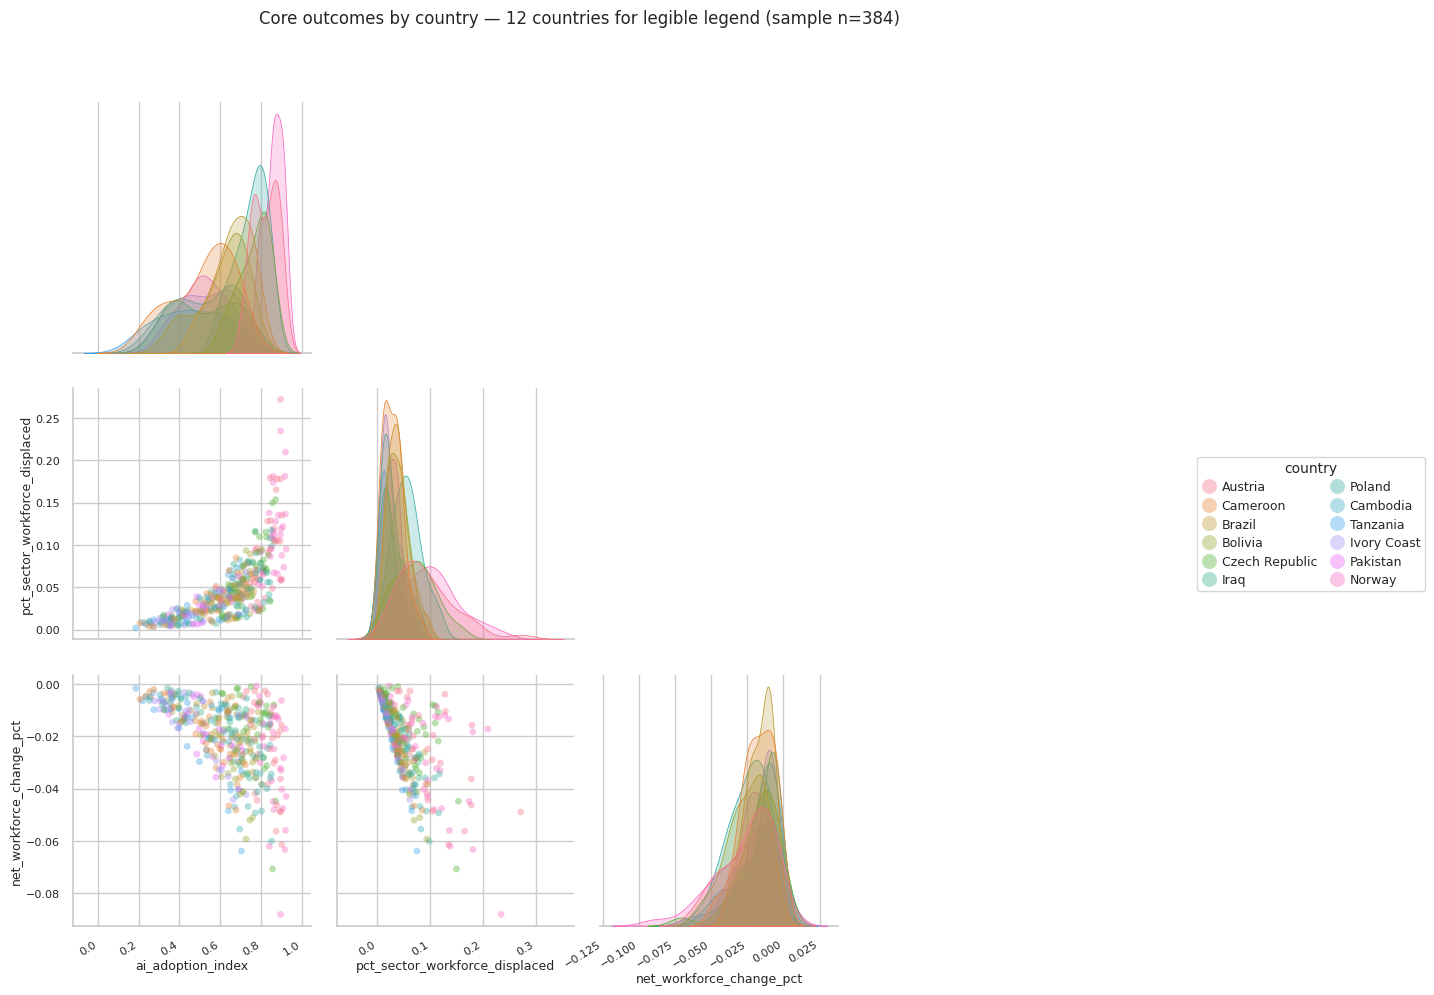

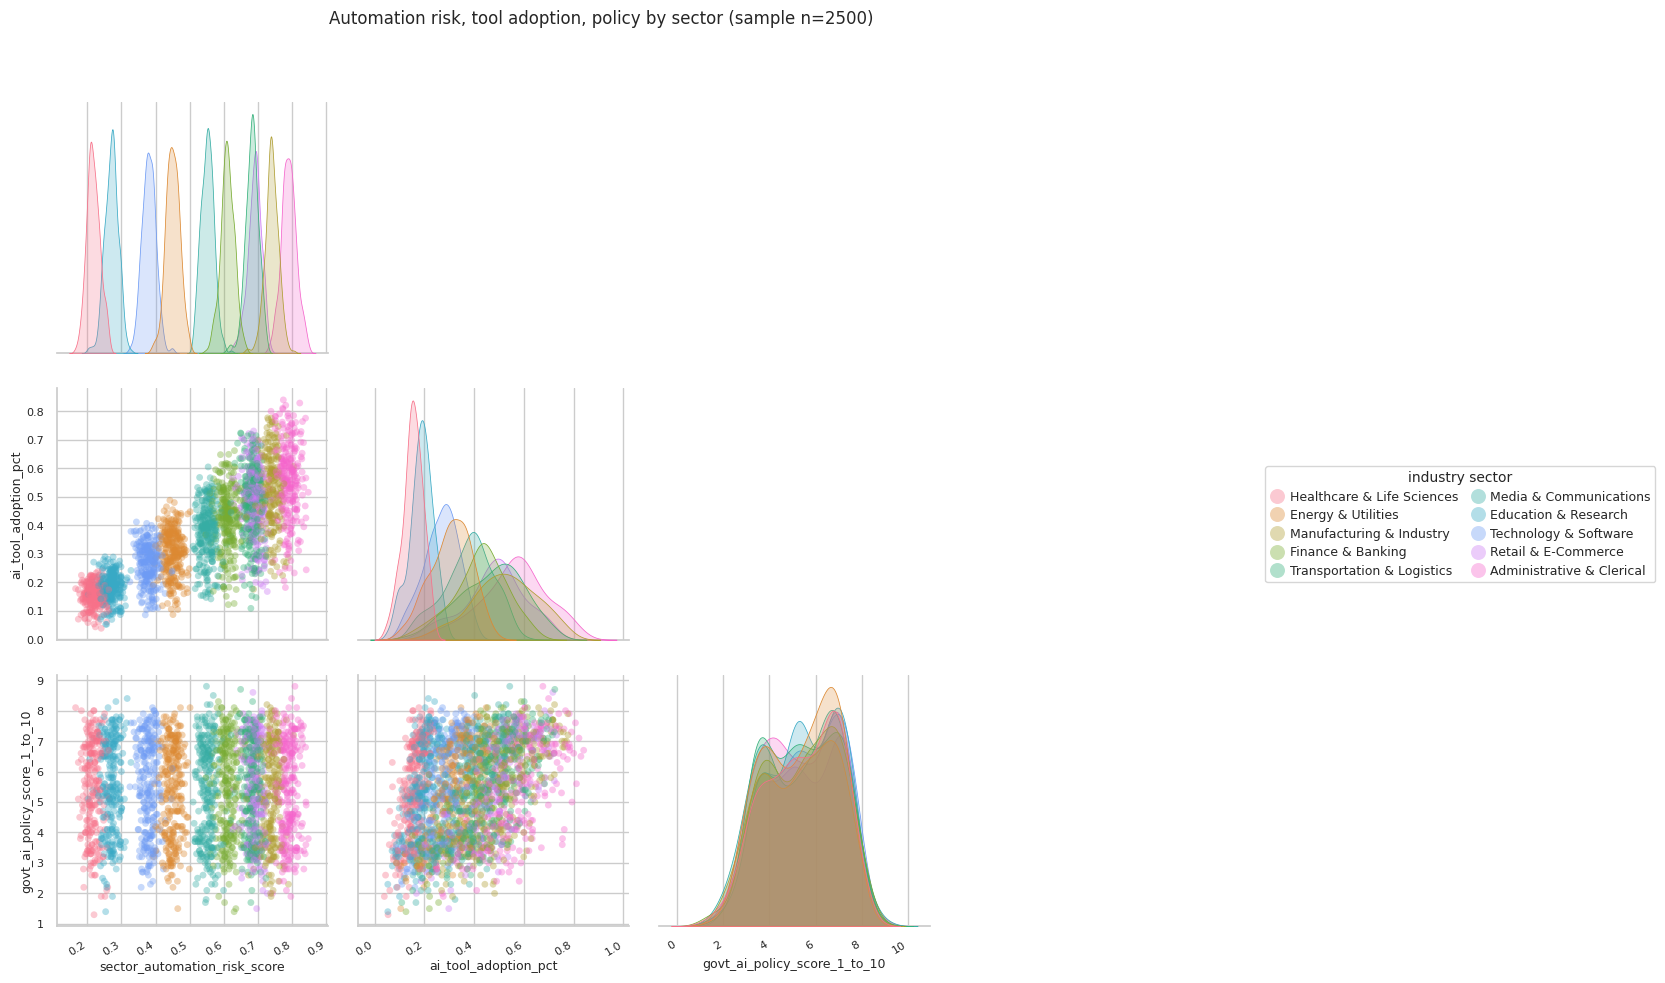

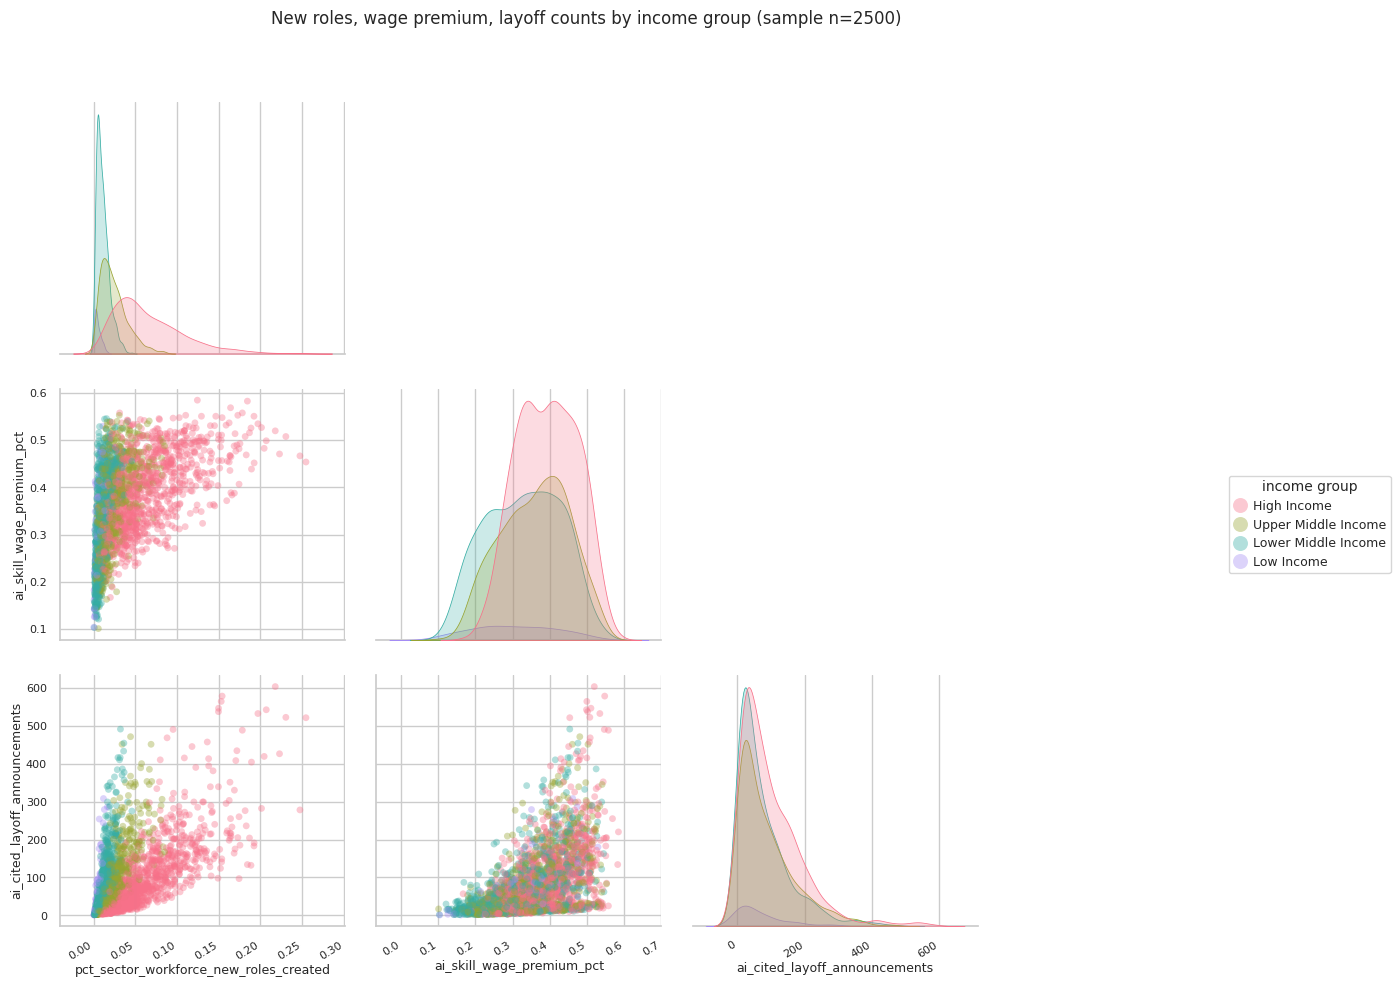

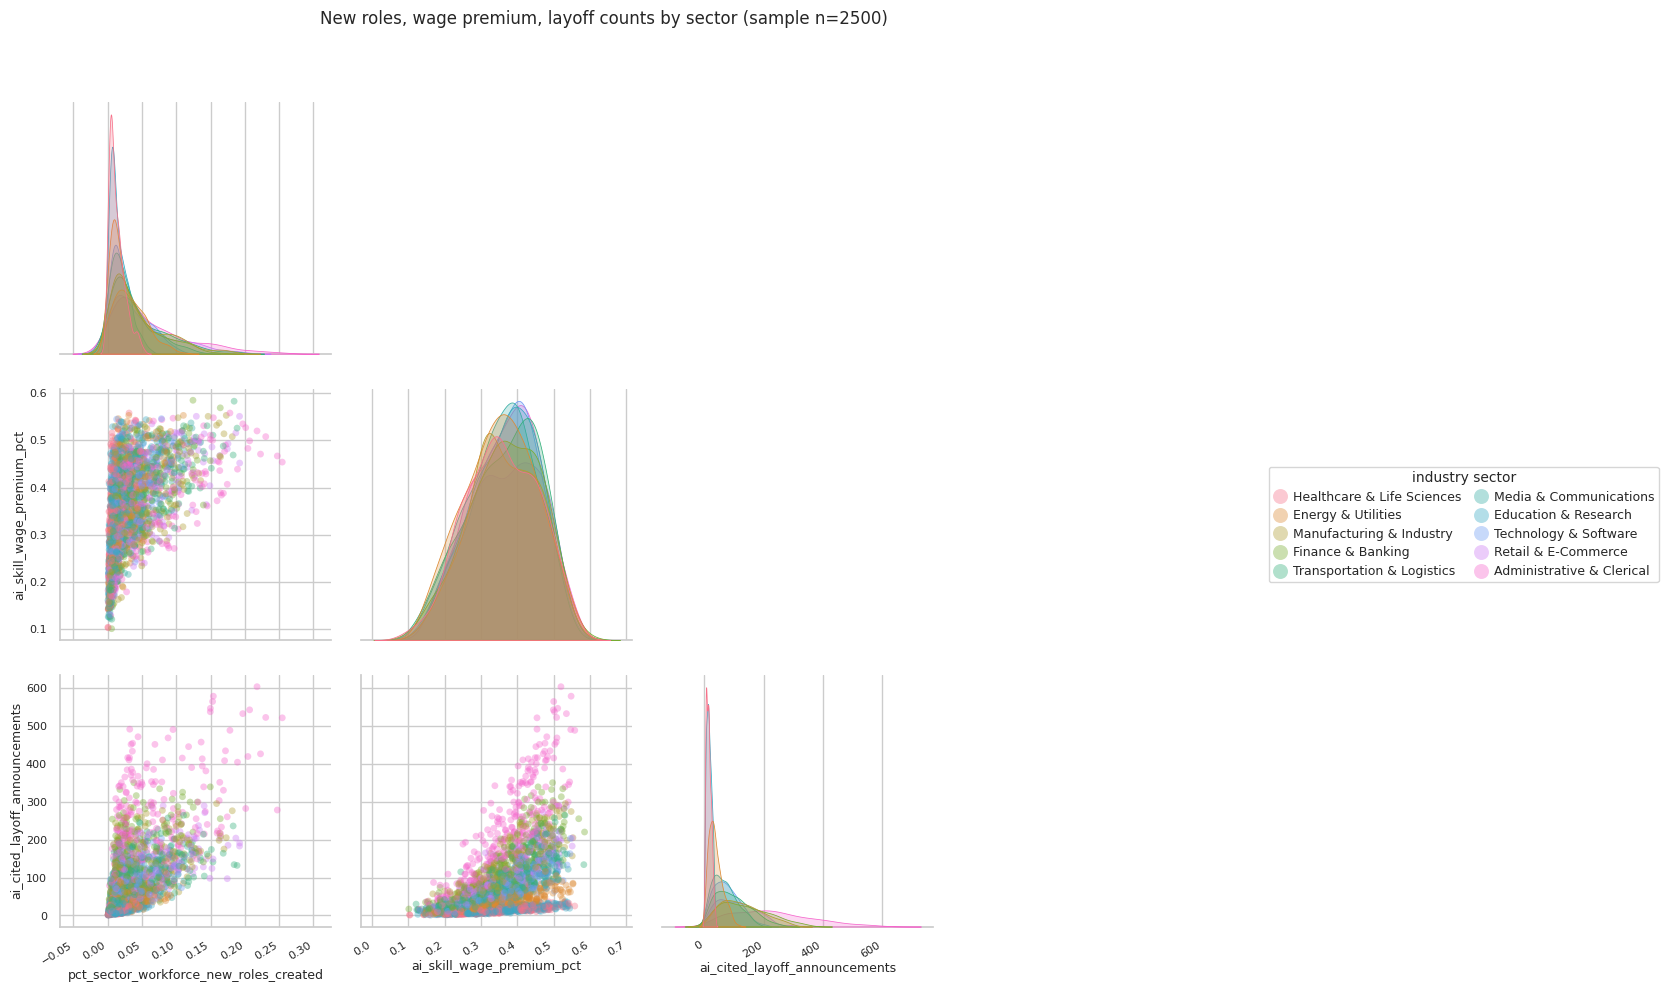

In [14]:
PAIR_SUBSET_N = min(2500, len(df))
rng = np.random.default_rng(42)
pair_ix = rng.choice(len(df), size=PAIR_SUBSET_N, replace=False)
_sample = df.iloc[pair_ix].reset_index(drop=True)

country_pick = np.array(sorted(df["country"].unique()))
countries_show = rng.choice(country_pick, size=min(12, len(country_pick)), replace=False)
_sample_country = _sample[_sample["country"].isin(countries_show)].copy()

cols_core = ["ai_adoption_index", "pct_sector_workforce_displaced", "net_workforce_change_pct"]
cols_alt = [
    "sector_automation_risk_score",
    "ai_tool_adoption_pct",
    "govt_ai_policy_score_1_to_10",
]
cols_roles = [
    "pct_sector_workforce_new_roles_created",
    "ai_skill_wage_premium_pct",
    "ai_cited_layoff_announcements",
]


def pairplot_big_legend(data, cols, hue, title):
    hue_n = int(data[hue].nunique())
    palette = sns.color_palette("husl", n_colors=max(hue_n, 3))
    # Larger cells + square-ish aspect so the grid uses the canvas better
    g = sns.pairplot(
        data[cols + [hue]],
        hue=hue,
        corner=True,
        height=3.35,
        aspect=1.0,
        plot_kws={"alpha": 0.38, "s": 24, "edgecolor": "none", "linewidth": 0},
        diag_kws={"linewidth": 0.55},
        palette=palette,
    )
    g.figure.suptitle(title, y=1.012, fontsize=12)

    # Avoid overlapping bottom-axis names / ticks (long column names)
    for ax in g.figure.axes:
        ax.tick_params(axis="both", labelsize=8)
        ax.tick_params(axis="x", labelrotation=32)
        for t in ax.get_xticklabels():
            t.set_horizontalalignment("right")
        xlab = ax.get_xlabel()
        if xlab:
            ax.set_xlabel(xlab, fontsize=9, labelpad=2)
        ylab = ax.get_ylabel()
        if ylab:
            ax.set_ylabel(ylab, fontsize=9, labelpad=2)

    if g._legend is not None:
        # Two columns when many categories → shorter legend, less dead horizontal gap
        ncol = 2 if hue_n > 6 else 1
        sns.move_legend(
            g,
            "center left",
            bbox_to_anchor=(1.02, 0.5),
            ncol=ncol,
            frameon=True,
            fontsize=9,
            title=str(hue).replace("_", " "),
            title_fontsize=10,
            markerscale=2.2,
            labelspacing=0.45,
            handlelength=1.15,
            handletextpad=0.45,
            borderpad=0.35,
            columnspacing=1.0,
        )

    # Reserve only the margin the legend needs (avoid a wide white strip)
    if hue_n > 10:
        right_margin = 0.72
    elif hue_n > 6:
        right_margin = 0.76
    else:
        right_margin = 0.82

    g.figure.subplots_adjust(
        left=0.07,
        right=right_margin,
        bottom=0.10,
        top=0.92,
        wspace=0.11,
        hspace=0.14,
    )
    plt.show()


pairplot_big_legend(
    _sample,
    cols_core,
    "income_group",
    f"Core outcomes by income group (sample n={len(_sample)})",
)
pairplot_big_legend(
    _sample,
    cols_core,
    "industry_sector",
    f"Core outcomes by industry sector (sample n={len(_sample)})",
)
pairplot_big_legend(
    _sample_country,
    cols_core,
    "country",
    f"Core outcomes by country — {len(countries_show)} countries for legible legend (sample n={len(_sample_country)})",
)
pairplot_big_legend(
    _sample,
    cols_alt,
    "industry_sector",
    f"Automation risk, tool adoption, policy by sector (sample n={len(_sample)})",
)
pairplot_big_legend(
    _sample,
    cols_roles,
    "income_group",
    f"New roles, wage premium, layoff counts by income group (sample n={len(_sample)})",
)
pairplot_big_legend(
    _sample,
    cols_roles,
    "industry_sector",
    f"New roles, wage premium, layoff counts by sector (sample n={len(_sample)})",
)



In [15]:
# RandomForest: predict net change from mixed features
feat_cat = ["region", "income_group", "industry_sector"]
feat_num = [
    "sector_automation_risk_score",
    "gdp_per_capita_usd",
    "ai_adoption_index",
    "ai_cited_layoff_announcements",
    "ai_skill_wage_premium_pct",
    "pct_workforce_female",
    "pct_displaced_roles_female",
    "reskilling_programs_count",
    "govt_ai_policy_score_1_to_10",
    "ai_tool_adoption_pct",
]
X = df[feat_cat + feat_num]
y = df["net_workforce_change_pct"]
pipe = Pipeline(
    [
        (
            "prep",
            ColumnTransformer(
                [
                    ("cat", OneHotEncoder(handle_unknown="ignore"), feat_cat),
                    ("num", "passthrough", feat_num),
                ]
            ),
        ),
        ("model", RandomForestRegressor(n_estimators=120, random_state=0, n_jobs=-1)),
    ]
)
pipe.fit(X, y)
enc = pipe.named_steps["prep"].named_transformers_["cat"]
cat_names = list(enc.get_feature_names_out(feat_cat))
imp = pipe.named_steps["model"].feature_importances_
names = cat_names + feat_num
imp_s = pd.Series(imp, index=names).sort_values(ascending=False).head(18)
print("Top RandomForest feature importances (predicting net_workforce_change_pct):")
print(imp_s.to_string())

Top RandomForest feature importances (predicting net_workforce_change_pct):
ai_cited_layoff_announcements               0.549686
ai_skill_wage_premium_pct                   0.076276
sector_automation_risk_score                0.063466
ai_adoption_index                           0.059543
gdp_per_capita_usd                          0.059333
ai_tool_adoption_pct                        0.048092
reskilling_programs_count                   0.046316
govt_ai_policy_score_1_to_10                0.038012
pct_displaced_roles_female                  0.027964
region_Europe                               0.004330
industry_sector_Finance & Banking           0.003679
region_Middle East                          0.002988
region_East Asia                            0.002457
region_North America                        0.002354
region_Oceania                              0.002122
pct_workforce_female                        0.001669
industry_sector_Manufacturing & Industry    0.001435
region_Latin America   

## 6 — Agent-readable synthesis

- **Velocity:** Use **QoQ deltas** (`dQ_*`) and **sector-level median |Δ displacement|** to see which industries are *noisiest* or *fast-moving* in this synthetic panel; use **per-series regression slopes** to compare *directional drift* over 2020–2026 across sectors.
- **Time paths:** Median **quarterly** curves by `industry_sector` summarise globalized sector stories; **facets by `income_group`** stress-test whether those paths split by development tier.
- **Country × sector:** The volatility-ranked **heatmap** highlights where mean `net_workforce_change_pct` diverges across sectors within the same country; **mean QoQ displacement change by country** ranks which country time-series tilt most up or down on average.
- **Multivariate:** The **correlation heatmap** and **pairplot** show co-movement of adoption, displacement, and net change; **RandomForest importances** give a nonlinear “what helps predict net change” view on top of linear correlation — all still associational.
- **Gender:** Compare `pct_displaced_roles_female` with `pct_workforce_female` in correlations and policy boxes; large gaps flag uneven composition of displacement in the synthetic story.